0) Optional: install dependencies

In [1]:
# Run only if you’re missing packages
%pip install wfdb scipy scikit-learn pandas numpy torch matplotlib joblib --quiet
# Optional (only for SMOTE ablation below):
%pip install imbalanced-learn --quiet


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


1) Setup & Reproducibility

In [2]:
# === Section 1: Setup & Reproducibility ===
import os, random, time, json, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    TORCH_OK = True
except Exception:
    TORCH_OK = False

def ts(): return time.strftime("%Y-%m-%d %H:%M:%S")
print("Seeds set. Torch available:", TORCH_OK, "| Time:", ts())


Seeds set. Torch available: True | Time: 2025-10-05 18:24:55


2) Dataset & Problem Definition (PTB-XL → Tabular features, 5-class by default)

In [3]:
# === Section 2: Dataset & Problem Definition (PTB-XL → 5- or 10-class) ===
PTBXL_ROOT = "PTB-XL2022/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

import os, pandas as pd, numpy as np, ast
from scipy.stats import skew, kurtosis

# Prefer local CSVs if present, else use files inside PTBXL_ROOT
DB_CSV  = "PTB-XL2022/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv"
SCP_CSV = "PTB-XL2022/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv"

assert os.path.exists(DB_CSV),  f"Missing {DB_CSV}"
assert os.path.exists(SCP_CSV), f"Missing {SCP_CSV}"
assert os.path.isdir(os.path.join(PTBXL_ROOT, "records100")), "Missing records100/"

LABEL_MODE = "5class"          # or "10class"
file_col   = "filename_lr"     # use "filename_hr" if you want records500

# Meta columns we preserve (NOT used as predictors)
META_FIELDS = [
    "ecg_id","patient_id","age","sex","height","weight","nurse","site","device",
    "recording_date","report","scp_codes","heart_axis","infarction_stadium1","infarction_stadium2",
    "validated_by","second_opinion","initial_autogenerated_report","validated_by_human",
    "baseline_drift","static_noise","burst_noise","electrodes_problems","extra_beats",
    "pacemaker","strat_fold"
]

# WFDB
try:
    import wfdb
except ImportError as e:
    raise RuntimeError("Please install WFDB:  %pip install wfdb") from e

# Optional quick sanity read
try:
    sig0, meta0 = wfdb.rdsamp(os.path.join(PTBXL_ROOT, "records100/00000/00001_lr"))
    print("WFDB OK:", sig0.shape, meta0.get("sig_name", []))
except Exception as e:
    print("WFDB sanity read failed (not fatal):", e)

# ---- Load CSVs ----
db  = pd.read_csv(DB_CSV)

# Robust SCP loader (ensures visible 'code' column and correct index)
scp_raw = pd.read_csv(SCP_CSV, encoding="utf-8-sig")
scp_raw.columns = [str(c).strip() for c in scp_raw.columns]

def extract_scp_keys(db_series, n=2000):
    keys = set()
    for s in db_series.head(min(n, len(db_series))):
        try:
            d = ast.literal_eval(s)
            keys.update(map(str, d.keys()))
        except Exception:
            pass
    return keys

known_keys = extract_scp_keys(db["scp_codes"], n=2000)
candidates = [c for c in scp_raw.columns if scp_raw[c].dtype == "object"]
scores = {c: len(set(scp_raw[c].astype(str)).intersection(known_keys)) for c in candidates}
code_col = max(scores, key=scores.get) if scores and max(scores.values())>0 else scp_raw.columns[0]

scp_raw["code"] = scp_raw[code_col].astype(str)
scp = scp_raw.set_index("code", drop=False)
scp.index.name = "code"

for req in ["diagnostic", "diagnostic_class", "diagnostic_subclass"]:
    if req not in scp.columns:
        raise ValueError(f"scp_statements.csv missing required column: '{req}'")

# --- FIX: robust handling of diagnostic column (1, 1.0, True, yes, etc.) ---
diag_col = scp["diagnostic"]

# numeric-positive OR truthy strings
diag_mask_num = pd.to_numeric(diag_col, errors="coerce").fillna(0) > 0
diag_mask_str = diag_col.astype(str).str.strip().str.lower().isin(
    ["1","1.0","true","t","yes","y","on"]
)
diag_mask = diag_mask_num | diag_mask_str

diag_only = scp.loc[diag_mask, ["diagnostic_class", "diagnostic_subclass"]].copy()

# Choose label field
label_field = "diagnostic_class" if LABEL_MODE == "5class" else "diagnostic_subclass"
valid_codes = set(diag_only.index)

print(f"Detected {len(valid_codes)} diagnostic SCP codes (of {len(scp)} total).")
if len(valid_codes) == 0:
    raise RuntimeError(
        "No diagnostic codes detected. Check 'diagnostic' values in scp_statements.csv "
        "(should be 1/1.0/True/yes)."
    )

def to_diag_label(scp_codes_dict):
    # scp_codes_dict like {"MI": 1.0, "NORM": 0.5, ...}
    try:
        keys = list(map(str, scp_codes_dict.keys()))
    except Exception:
        return None
    keep = [k for k in keys if k in valid_codes]
    if not keep:
        return None
    labels = [diag_only.loc[k, label_field] for k in keep]
    vals, cnts = np.unique(labels, return_counts=True)
    return vals[np.argmax(cnts)]

# ---- Build features ----
rows, skipped_read, skipped_label = [], 0, 0
MAX_RECORDS = None  # set to a small int for a quick smoke test
count = 0

for _, r in db.iterrows():
    if MAX_RECORDS is not None and count >= MAX_RECORDS:
        break

    feats = {}
    # copy meta fields with light normalization
    for k in META_FIELDS:
        val = r.get(k, np.nan)
        if k == "recording_date":
            try:
                feats[k] = pd.to_datetime(val).date().isoformat()
            except Exception:
                feats[k] = np.nan
        else:
            feats[k] = val

    # target label
    try:
        scp_codes = ast.literal_eval(r["scp_codes"])
    except Exception:
        skipped_label += 1
        continue

    y = to_diag_label(scp_codes)
    if y is None:
        continue

    # read signal
    rec_dat   = os.path.join(PTBXL_ROOT, r[file_col])  # e.g., records100/.../_lr.dat
    rec_noext = rec_dat[:-4] if rec_dat.endswith(".dat") else rec_dat
    try:
        sig, meta = wfdb.rdsamp(rec_noext)  # (timesteps, 12 leads)
    except Exception:
        skipped_read += 1
        continue

    feats["record_path"] = rec_noext  # for later inspection

    # per-lead robust stats
    for j in range(sig.shape[1]):
        x = sig[:, j].astype(np.float32)
        feats[f"L{j}_mean"] = float(np.mean(x))
        feats[f"L{j}_std"]  = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
        feats[f"L{j}_rms"]  = float(np.sqrt(np.mean(x**2)))
        feats[f"L{j}_p25"]  = float(np.percentile(x, 25))
        feats[f"L{j}_p50"]  = float(np.percentile(x, 50))
        feats[f"L{j}_p75"]  = float(np.percentile(x, 75))
        try:   feats[f"L{j}_skew"] = float(skew(x))
        except: feats[f"L{j}_skew"] = 0.0
        try:   feats[f"L{j}_kurt"] = float(kurtosis(x))
        except: feats[f"L{j}_kurt"] = 0.0

    feats["label"] = y
    rows.append(feats); count += 1

# Convert to DataFrame and basic checks
if not rows:
    raise RuntimeError(
        "Feature extraction produced 0 rows. Most likely no records matched diagnostic labels.\n"
        "Confirm scp_statements.csv 'diagnostic' column and that ptbxl_database.csv scp_codes "
        "contain codes present in scp_statements.csv."
    )

df = pd.DataFrame(rows)
OUT_CSV = "PTB-XL2022/ptbxl_features.csv"
df.to_csv(OUT_CSV, index=False)
print(f"Saved features: {OUT_CSV} | shape: {df.shape} | label mode: {LABEL_MODE}")
print("Class counts:\n", df["label"].value_counts())
print("Skipped reads:", skipped_read, "| skipped label parse:", skipped_label)


WFDB OK: (1000, 12) ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Detected 44 diagnostic SCP codes (of 71 total).
Saved features: PTB-XL2022/ptbxl_features.csv | shape: (21388, 124) | label mode: 5class
Class counts:
 label
NORM    9097
CD      4413
MI      3540
STTC    2588
HYP     1750
Name: count, dtype: int64
Skipped reads: 0 | skipped label parse: 0


3) EDA

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,L10_kurt,L11_mean,L11_std,L11_rms,L11_p25,L11_p50,L11_p75,L11_skew,L11_kurt,label
0,1,15709,56,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09,...,12.147693,0.000832,0.101990,0.101943,-0.069,-0.0110,0.03300,1.839972,5.115987,NORM
1,2,13243,19,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14,...,27.429422,0.003389,0.186720,0.186657,-0.094,-0.0215,0.02500,4.224206,24.103996,NORM
2,3,20372,37,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15,...,19.571331,0.004239,0.100892,0.100931,-0.060,-0.0130,0.05325,2.914357,13.329775,NORM
3,4,17014,24,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15,...,8.050313,-0.004061,0.298061,0.297940,-0.182,-0.0790,0.08800,2.007729,6.758060,NORM
4,5,17448,19,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17,...,19.030163,-0.000053,0.180299,0.180209,-0.093,-0.0440,0.00900,4.030639,20.116993,NORM


,count,mean,std,min,25%,50%,75%,max
ecg_id,21388.0,10891.272115,6300.265743,1.000000,5431.750000,10862.500000,16349.250000,21837.000000
patient_id,21388.0,11210.154432,6240.997937,302.000000,5915.750000,11360.500000,16568.250000,21797.000000
age,21388.0,62.608753,32.235489,2.000000,50.000000,62.000000,72.000000,300.000000
sex,21388.0,0.480503,0.499631,0.000000,0.000000,0.000000,1.000000,1.000000
height,6918.0,166.694565,10.869989,6.000000,160.000000,166.000000,174.000000,209.000000
weight,9366.0,71.020500,15.877360,5.000000,60.000000,70.000000,80.000000,250.000000
nurse,19949.0,2.313900,3.261345,0.000000,0.000000,1.000000,4.000000,11.000000
site,21372.0,1.558675,4.201119,0.000000,0.000000,1.000000,2.000000,50.000000
validated_by,12296.0,0.745690,1.179663,0.000000,0.000000,1.000000,1.000000,11.000000
strat_fold,21388.0,5.502992,2.875975,1.000000,3.000000,6.000000,8.000000,10.000000



Class distribution:


label
NORM    9097
CD      4413
MI      3540
STTC    2588
HYP     1750
Name: count, dtype: int64

pacemaker              0.999345
electrodes_problems    0.998691
infarction_stadium2    0.995184
burst_noise            0.972835
baseline_drift         0.926174
extra_beats            0.912007
static_noise           0.850103
infarction_stadium1    0.738171
height                 0.676548
weight                 0.562091
validated_by           0.425098
heart_axis             0.381522
nurse                  0.067281
site                   0.000748
L10_skew               0.000047
L10_kurt               0.000047
L7_std                 0.000000
L8_rms                 0.000000
L8_std                 0.000000
L7_rms                 0.000000
dtype: float64

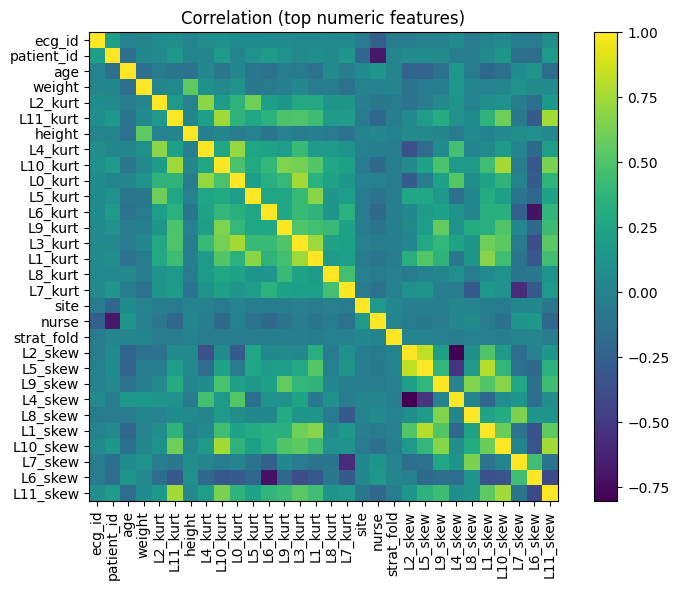

In [4]:
# === Section 3: EDA ===
display(df.head())
display(df.describe().T.iloc[:12])

print("\nClass distribution:")
display(df["label"].value_counts())

# Missingness overview
na_rate = df.isna().mean().sort_values(ascending=False)
display(na_rate.head(20))

# Correlation heatmap for top-variance numeric features
import matplotlib.pyplot as plt
num_df = df.select_dtypes(include=[np.number]).copy()
var = num_df.var().sort_values(ascending=False)
top_cols = var.index[:30] if len(var) >= 30 else var.index
corr = num_df[top_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation='nearest')
plt.title("Correlation (top numeric features)")
plt.xticks(range(len(top_cols)), top_cols, rotation=90)
plt.yticks(range(len(top_cols)), top_cols)
plt.colorbar(); plt.tight_layout(); plt.show()


Pearson (all numeric): (106, 106)


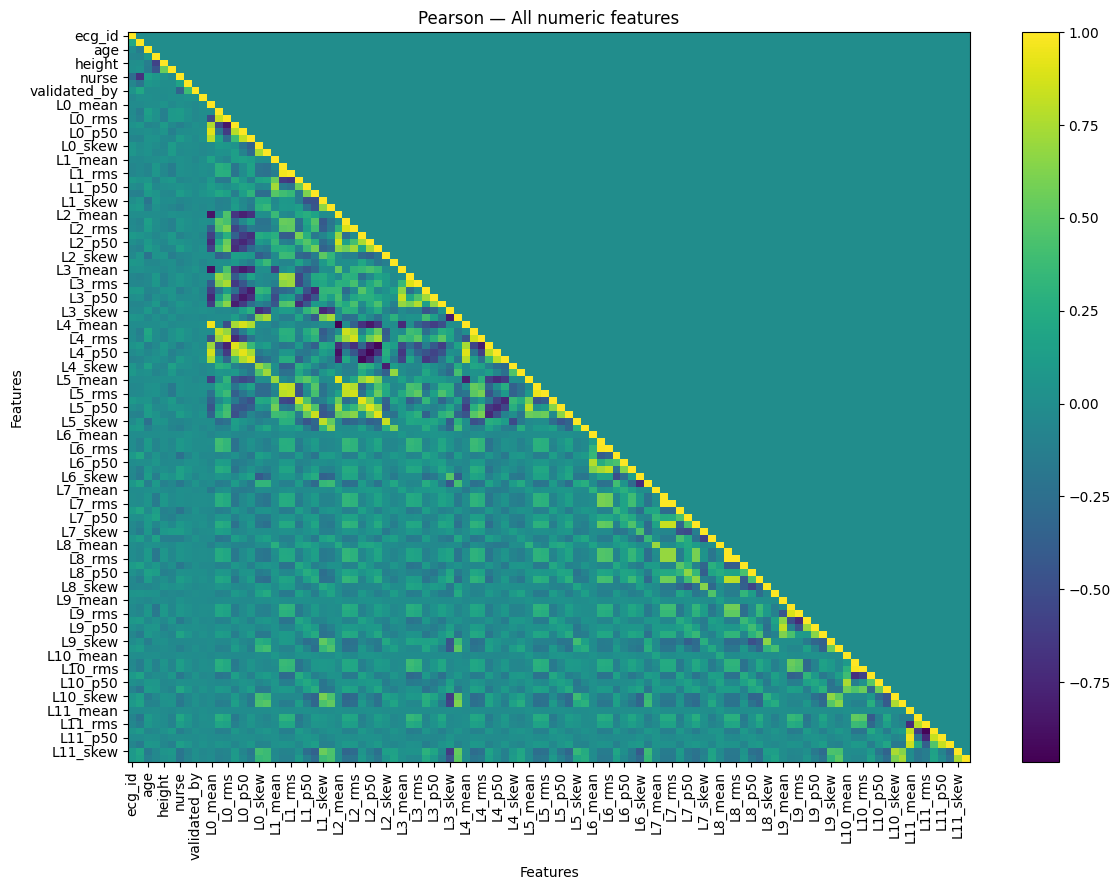

,f1,f2,|r|
5100,L8_std,L8_rms,0.998922
4824,L7_std,L7_rms,0.998251
4484,L6_std,L6_rms,0.979619
5460,L10_std,L10_rms,0.970992
5540,L11_mean,L11_p50,0.965862
2420,L2_mean,L4_mean,0.964317
1824,L1_std,L1_rms,0.963509
1036,L0_mean,L4_mean,0.959682
4080,L5_std,L5_rms,0.942678
5550,L11_rms,L11_p25,0.940883


Pearson (+age/sex): (107, 107)


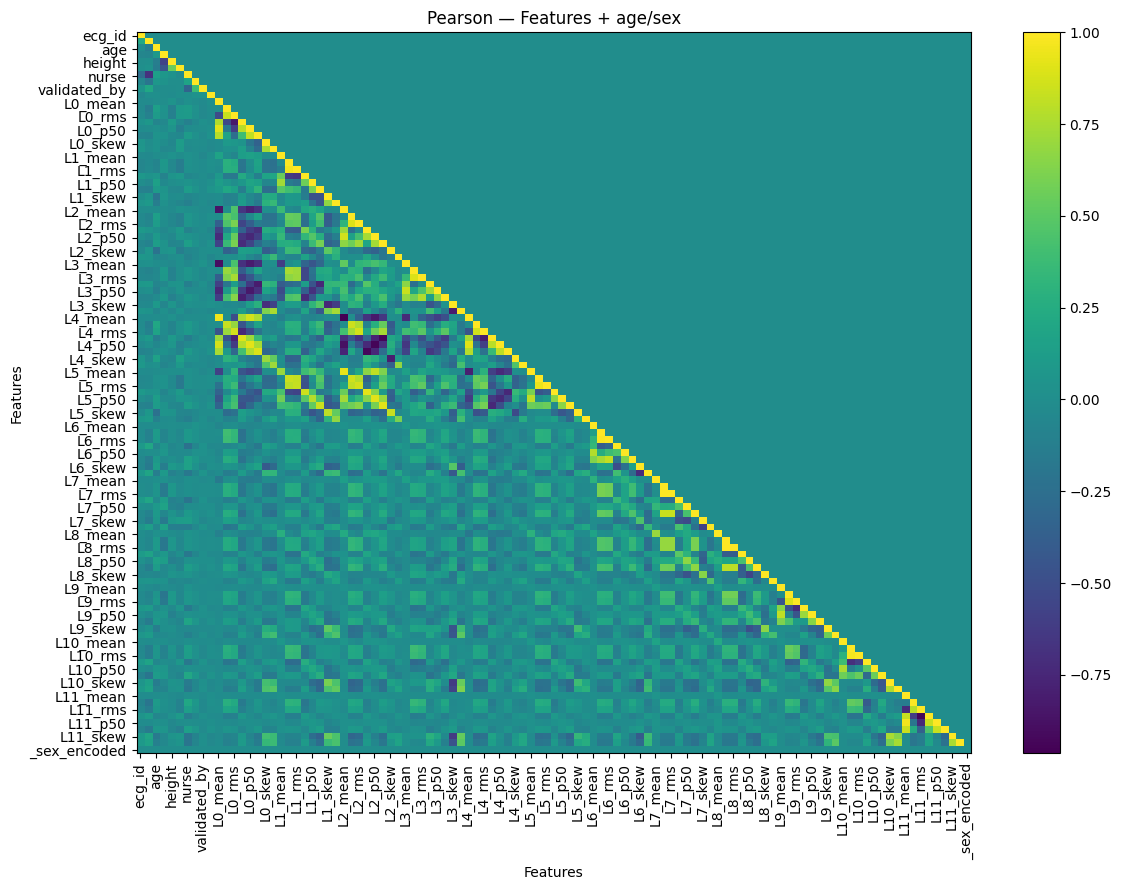

,f1,f2,|r|
5175,L8_std,L8_rms,0.998922
4891,L7_std,L7_rms,0.998251
4543,L6_std,L6_rms,0.979619
5551,L10_std,L10_rms,0.970992
5638,L11_mean,L11_p50,0.965862
2446,L2_mean,L4_mean,0.964317
1843,L1_std,L1_rms,0.963509
1046,L0_mean,L4_mean,0.959682
4131,L5_std,L5_rms,0.942678
5650,L11_rms,L11_p25,0.940883


Cramér’s V: (10, 10)


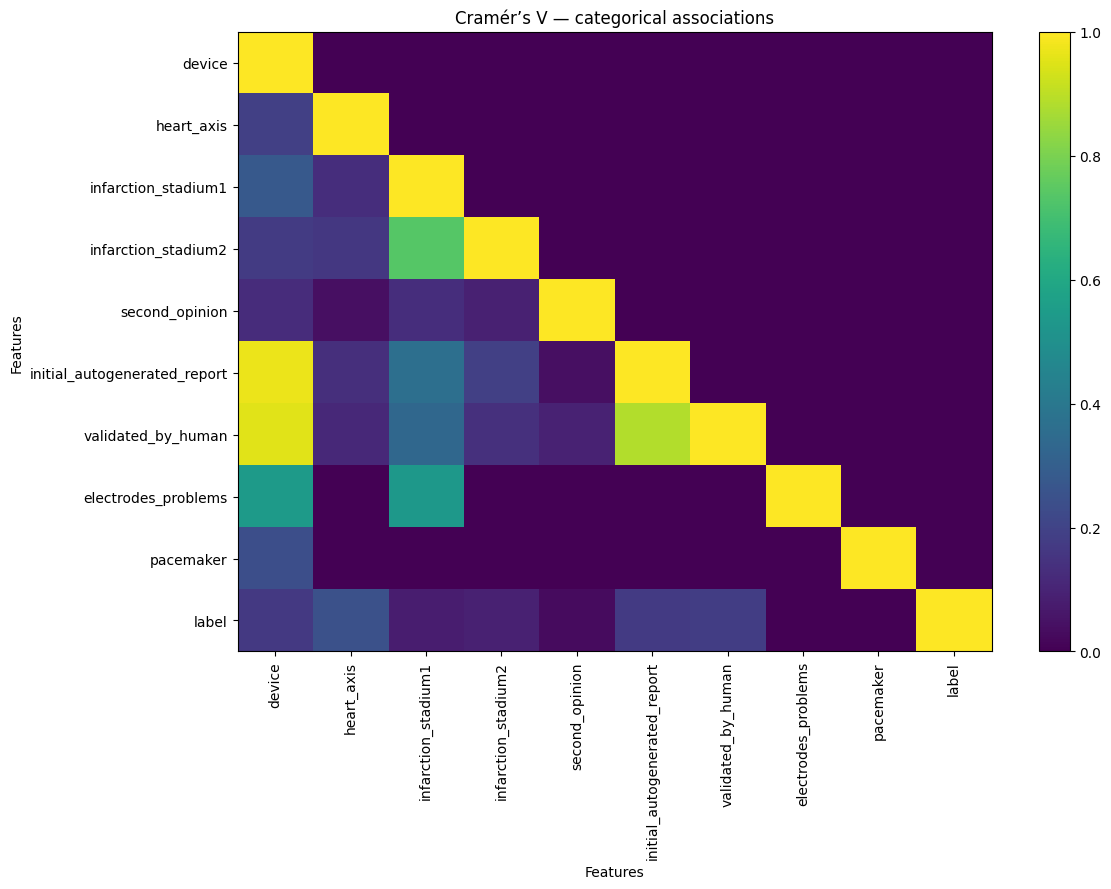

Computing MI with target: label
Top MI features:


scp_codes              1.335232
report                 0.727224
infarction_stadium1    0.373670
L1_skew                0.127049
L9_p50                 0.106209
L1_p50                 0.103303
L3_skew                0.100799
heart_axis             0.099430
L3_p50                 0.097339
L4_rms                 0.089649
L9_skew                0.087302
patient_id             0.085503
L10_p50                0.085282
L5_skew                0.085107
L4_std                 0.085062
L10_p25                0.084258
L9_p25                 0.083604
L5_p50                 0.083209
age                    0.082999
L1_p25                 0.082260
dtype: float64


Artifacts saved in: test/artifacts


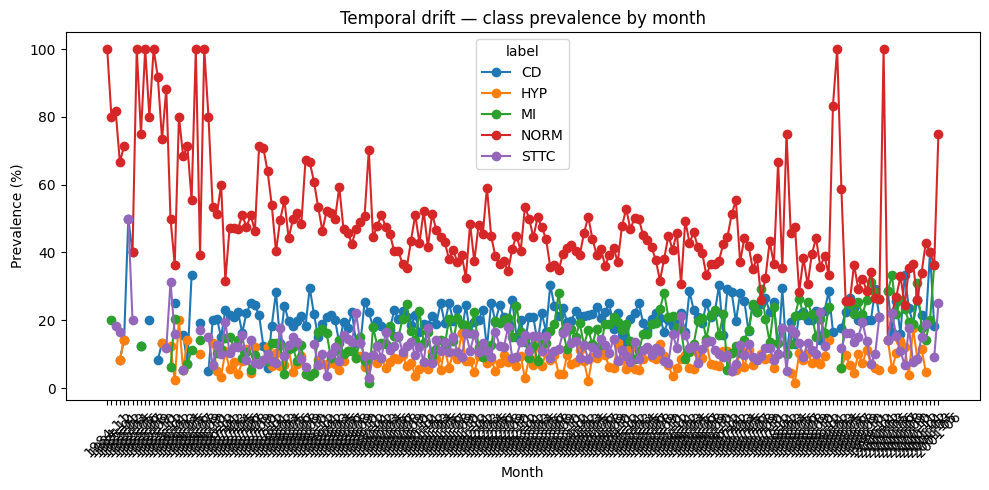

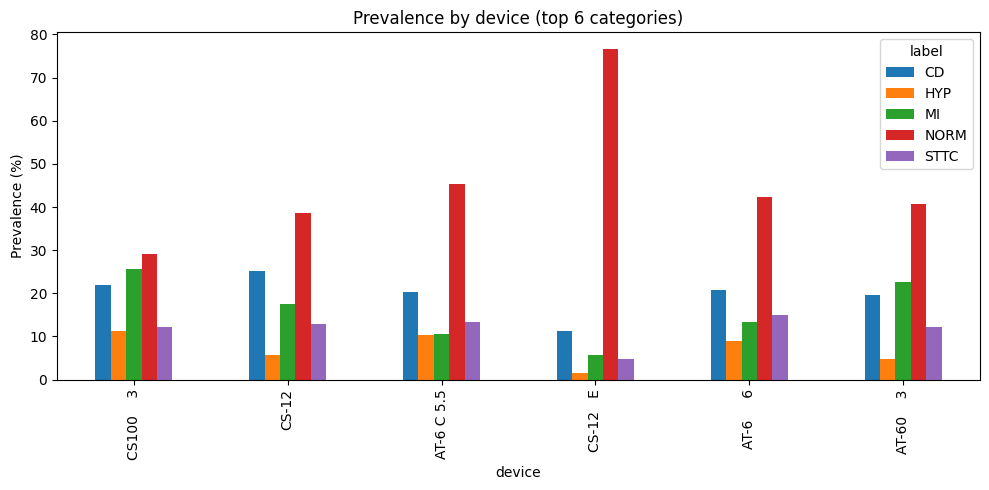

device: chi2=2276.8, dof=20, p=0.000e+00 (association strength)


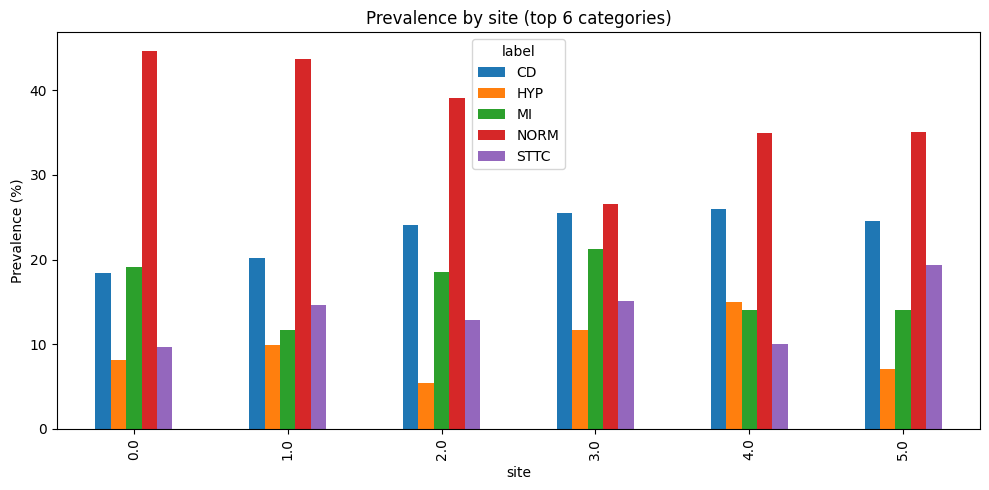

site: chi2=425.8, dof=20, p=8.809e-78 (association strength)


,feature,VIF
38,L8_std,inf
37,L8_rms,inf
36,L7_std,inf
35,L7_rms,inf
13,L3_kurt,16.708572
31,L3_skew,15.688615
20,L2_skew,10.929975
9,L0_kurt,10.784598
21,L5_skew,10.241322
25,L1_skew,9.861497


No preprocessor/X_train found — using numeric columns from df instead.


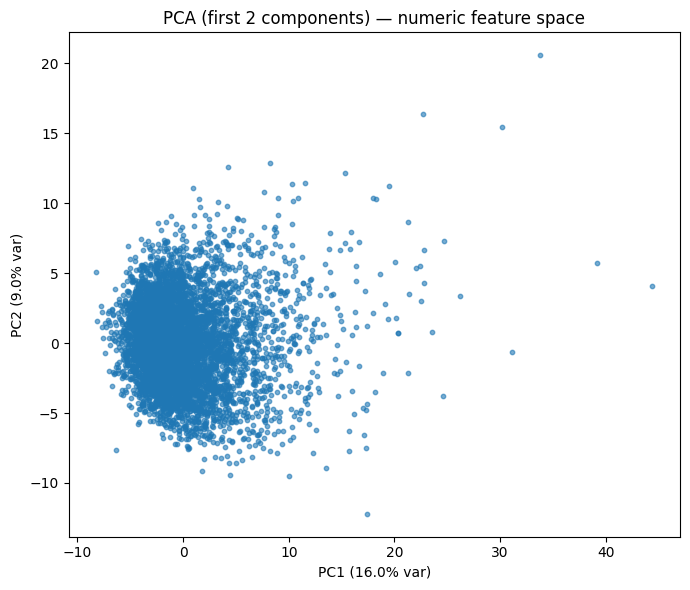

Noise slice skipped — missing noise metadata or trained RandomForest/X_test.
Leakage audit skipped — patient_id or train/test indices not available.


In [5]:
# %% [markdown]
# === Section 3.X — Extended Correlation & Feature Analysis (Option B + Robust MI) ===
# Outputs are written to test/artifacts/

# %%
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")
ART_DIR = "test/artifacts"; os.makedirs(ART_DIR, exist_ok=True)

# ---------- helpers ----------
def _downsampled_axis(ax, labels):
    n = len(labels); max_ticks = 40
    if n > max_ticks:
        step = max(1, n // max_ticks)
        idxs = list(range(0, n, step))
        ax.set_xticks(idxs); ax.set_yticks(idxs)
        ax.set_xticklabels([labels[i] for i in idxs], rotation=90)
        ax.set_yticklabels([labels[i] for i in idxs])
    else:
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(labels, rotation=90); ax.set_yticklabels(labels)

def _plot_corr(corr: pd.DataFrame, title: str):
    cm = corr.copy()
    mask = np.triu(np.ones(cm.shape, dtype=bool), 1)  # boolean upper-triangle
    cm_masked = cm.mask(mask).fillna(0.0)
    fig, ax = plt.subplots(figsize=(12,9))
    im = ax.imshow(cm_masked.values, aspect="auto", interpolation="nearest")
    ax.set_title(title); ax.set_xlabel("Features"); ax.set_ylabel("Features")
    _downsampled_axis(ax, list(cm_masked.columns))
    fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

# ✅ Option B: robust NumPy-based correlation pair ranking
def _top_abs_pairs(corr: pd.DataFrame, n: int = 30) -> pd.DataFrame:
    cm = corr.abs().to_numpy()
    cols = corr.columns.to_numpy()
    i_upper, j_upper = np.triu_indices_from(cm, k=1)
    pairs = pd.DataFrame({
        "f1": cols[i_upper],
        "f2": cols[j_upper],
        "|r|": cm[i_upper, j_upper],
    }).sort_values("|r|", ascending=False).head(n)
    return pairs

def _cramers_v_matrix(df_cat: pd.DataFrame) -> pd.DataFrame:
    cats = [c for c in df_cat.columns if df_cat[c].nunique(dropna=True) > 1]
    n = len(cats)
    out = pd.DataFrame(np.eye(n), index=cats, columns=cats, dtype=float)
    for i in range(n):
        for j in range(i+1, n):
            a, b = cats[i], cats[j]
            tbl = pd.crosstab(df_cat[a], df_cat[b])
            if tbl.shape[0] < 2 or tbl.shape[1] < 2:
                v = np.nan
            else:
                chi2, _, _, _ = chi2_contingency(tbl, correction=False)
                nobs = float(tbl.values.sum())
                r, k = tbl.shape
                phi2 = chi2 / max(nobs, 1.0)
                # Bias correction
                phi2corr = max(0.0, phi2 - (k-1)*(r-1)/max(nobs-1, 1.0))
                rcorr = r - (r-1)**2 / max(nobs-1, 1.0)
                kcorr = k - (k-1)**2 / max(nobs-1, 1.0)
                denom = min((kcorr-1), (rcorr-1))
                v = np.sqrt(phi2corr / denom) if denom and denom > 0 else np.nan
            out.iloc[i, j] = out.iloc[j, i] = v
    return out

# Robust MI that handles NaNs/Infs & categoricals
def _mutual_info(df_in: pd.DataFrame, target: str) -> pd.Series:
    """
    - encodes categoricals
    - replaces +/- inf with NaN
    - imputes NaN (median for numeric, most_frequent for categorical)
    - drops constant columns
    - MI regression if target numeric else MI classification
    """
    if target not in df_in.columns:
        raise ValueError(f"Target '{target}' not found.")
    df = df_in.copy()
    y = df[target]
    X = df.drop(columns=[target])

    # Split by dtype
    X_num = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
    X_cat = X.select_dtypes(include=["object", "category", "bool"]).copy()

    # Encode categoricals
    for c in X_cat.columns:
        X_cat[c] = X_cat[c].astype(str)
        X_cat[c] = LabelEncoder().fit_transform(X_cat[c])

    parts = []
    if not X_num.empty:
        num_imp = SimpleImputer(strategy="median")
        X_num = pd.DataFrame(num_imp.fit_transform(X_num), columns=X_num.columns, index=X.index)
        parts.append(X_num)
    if not X_cat.empty:
        cat_imp = SimpleImputer(strategy="most_frequent")
        X_cat = pd.DataFrame(cat_imp.fit_transform(X_cat), columns=X_cat.columns, index=X.index)
        parts.append(X_cat)

    if not parts:
        raise ValueError("No usable features for MI.")
    X_imp = pd.concat(parts, axis=1)

    # Drop constant columns
    var = X_imp.var(axis=0)
    keep = var[var > 0].index
    if len(keep) == 0:
        raise ValueError("All features constant after preprocessing.")
    X_imp = X_imp[keep]

    # Choose MI flavor
    if y.dtype.kind in "ifu":
        y_num = pd.to_numeric(y, errors="coerce").replace([np.inf, -np.inf], np.nan)
        mask = y_num.notna()
        X_use = X_imp.loc[mask]
        y_use = y_num.loc[mask]
        if X_use.shape[0] < 3:
            raise ValueError("Not enough valid rows for MI regression.")
        mi_vals = mutual_info_regression(X_use, y_use, random_state=42)
    else:
        y_enc = LabelEncoder().fit_transform(y.astype(str))
        if X_imp.shape[0] < 3:
            raise ValueError("Not enough rows for MI classification.")
        mi_vals = mutual_info_classif(X_imp, y_enc, random_state=42)

    return pd.Series(mi_vals, index=X_imp.columns).sort_values(ascending=False)

# ---------- 3.1) Pearson — all numeric ----------
num = df.select_dtypes(include=[np.number])
if num.shape[1] > 1:
    corr_all = num.corr(method="pearson")
    corr_all.to_csv(f"{ART_DIR}/corr_all_numeric.csv")
    print("Pearson (all numeric):", corr_all.shape)
    _plot_corr(corr_all, "Pearson — All numeric features")
    top30_all = _top_abs_pairs(corr_all)
    top30_all.to_csv(f"{ART_DIR}/top30_abs_corr_all_numeric.csv", index=False)
    display(top30_all.head(10))
else:
    print("Not enough numeric columns for Pearson correlation.")

# ---------- 3.2) Pearson — numeric + metadata (age/sex) ----------
_df_tmp = df.copy()
if "sex" in _df_tmp.columns:
    _df_tmp["_sex_encoded"] = _df_tmp["sex"].astype(str).str.lower().str.strip() \
        .map({"male":0, "m":0, "female":1, "f":1})
keep = list(_df_tmp.select_dtypes(include=[np.number]).columns)
for extra in ["age", "_sex_encoded"]:
    if extra in _df_tmp.columns and extra not in keep:
        keep.append(extra)
num_meta = _df_tmp[keep]
if num_meta.shape[1] > 1:
    corr_meta = num_meta.corr(method="pearson")
    corr_meta.to_csv(f"{ART_DIR}/corr_features_plus_age_sex.csv")
    print("Pearson (+age/sex):", corr_meta.shape)
    _plot_corr(corr_meta, "Pearson — Features + age/sex")
    top30_meta = _top_abs_pairs(corr_meta)
    top30_meta.to_csv(f"{ART_DIR}/top30_abs_corr_features_plus_age_sex.csv", index=False)
    display(top30_meta.head(10))
else:
    print("Not enough numeric columns for extended Pearson (+age/sex).")

# ---------- 3.3) Cramér’s V — categorical vs categorical ----------
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
cat_keep = [c for c in cat_cols if 2 <= df[c].nunique(dropna=True) <= 50]
if len(cat_keep) >= 2:
    cram = _cramers_v_matrix(df[cat_keep])
    cram.to_csv(f"{ART_DIR}/cramers_v_matrix.csv")
    print("Cramér’s V:", cram.shape)
    _plot_corr(cram.fillna(0.0), "Cramér’s V — categorical associations")
else:
    print("No suitable categorical columns (2–50 unique) for Cramér’s V.")

# ---------- 3.4) Mutual Information — mixed relevance ----------
candidate_targets = [c for c in ["label","diagnostic_class","superclass","target"] if c in df.columns]
if candidate_targets:
    tgt = candidate_targets[0]
    print("Computing MI with target:", tgt)
    try:
        mi = _mutual_info(df.dropna(subset=[tgt], how="all"), tgt)
        mi.head(30).to_csv(f"{ART_DIR}/mi_top30.csv")
        print("Top MI features:"); display(mi.head(20))
    except Exception as e:
        print("MI skipped:", e)
else:
    print("No obvious target column found for Mutual Information (e.g., 'label').")

print(f"\nArtifacts saved in: {ART_DIR}")

# === 3.5: Temporal drift — label prevalence by month (safe version) ===
_df = df.copy()
# Parse recording_date robustly (string or datetime); skip if column missing
if "recording_date" in _df.columns:
    _df["recording_dt"] = pd.to_datetime(_df["recording_date"], errors="coerce")
else:
    _df["recording_dt"] = pd.NaT
# Month key
_df["ym"] = _df["recording_dt"].dt.to_period("M").astype(str)
# Count per (ym, label)
counts = (
    _df.groupby(["ym", "label"], as_index=False)
       .size()
       .rename(columns={"size": "n"})
)
# Remove rows where ym is NA (unparsable dates)
counts = counts[counts["ym"].notna()].copy()
# Prevalence (%) within each month
counts["pct"] = counts["n"] / counts.groupby("ym")["n"].transform("sum") * 100
# Sort months chronologically if possible
try:
    ym_order = np.sort(counts["ym"].unique())
except Exception:
    ym_order = counts["ym"].unique()
plt.figure(figsize=(10, 5))
for c in sorted(counts["label"].dropna().unique()):
    m = counts["label"] == c
    ser = counts.loc[m, ["ym", "pct"]].set_index("ym").reindex(ym_order)
    plt.plot(ser.index, ser["pct"].values, marker="o", label=str(c))
plt.title("Temporal drift — class prevalence by month")
plt.xlabel("Month"); plt.ylabel("Prevalence (%)")
plt.legend(title="label"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# === 3.6: Batch effects — device/site vs label ===
def prevalence_bar(df_in, col, top=6):
    counts = pd.crosstab(df_in[col], df_in["label"])
    total = counts.sum(axis=1)
    top_idx = total.sort_values(ascending=False).head(top).index
    sub = counts.loc[top_idx]
    prev = sub.div(sub.sum(axis=1), axis=0) * 100
    prev.plot(kind="bar", figsize=(10,5))
    plt.title(f"Prevalence by {col} (top {top} categories)")
    plt.xlabel(col); plt.ylabel("Prevalence (%)")
    plt.legend(title="label"); plt.tight_layout(); plt.show()
    chi2, p, dof, _ = chi2_contingency(sub.values)
    print(f"{col}: chi2={chi2:.1f}, dof={dof}, p={p:.3e} (association strength)")

for col in ["device","site"]:
    if col in df.columns:
        prevalence_bar(df, col, top=6)

# === 3.7: Collinearity (VIF) — top-variance numeric features ===
def vif_table(X: pd.DataFrame):
    vifs = []
    X_ = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    if X_.shape[1] < 2 or X_.shape[0] < 5:
        return pd.DataFrame({"feature": X.columns, "VIF": np.nan})
    for col in X_.columns:
        y = X_[col].values
        Xrest = X_.drop(columns=[col]).values
        try:
            r2 = LinearRegression().fit(Xrest, y).score(Xrest, y)
        except Exception:
            r2 = np.nan
        vif = np.inf if (r2 is not None and r2 >= 0.999999) else (1.0 / max(1e-12, 1 - (r2 if r2==r2 else 0)))
        vifs.append((col, float(vif)))
    return pd.DataFrame(vifs, columns=["feature","VIF"]).sort_values("VIF", ascending=False)

num_all = df.select_dtypes(include=[np.number])
var = num_all.var().sort_values(ascending=False)
cols = var.index[:40] if len(var) > 40 else var.index
vif_df = vif_table(num_all[cols])
display(vif_df.head(20))

# === 3.8: PCA visualization — safe fallback (uses preprocessor if available) ===
# If your training pipeline exists, it will be used; otherwise we use scaled numeric df.
if "preprocessor" in locals() and "X_train" in locals() and "y_train" in locals():
    print("Using model preprocessor and training split for PCA visualization.")
    Xtr = preprocessor.fit_transform(X_train)
    ytr = y_train.values
    if not isinstance(Xtr, np.ndarray):
        Xtr = Xtr.toarray()
else:
    print("No preprocessor/X_train found — using numeric columns from df instead.")
    num_cols = df.select_dtypes(include=[np.number]).columns
    Xtr = df[num_cols].replace([np.inf, -np.inf], np.nan).dropna()
    Xtr = StandardScaler().fit_transform(Xtr)
    ytr = np.zeros(Xtr.shape[0])  # dummy labels

pca = PCA(n_components=2, random_state=42)
emb = pca.fit_transform(Xtr)
plt.figure(figsize=(7,6))
plt.scatter(emb[:,0], emb[:,1], s=10, alpha=0.6)
plt.title("PCA (first 2 components) — numeric feature space")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout(); plt.show()

# === 3.9: Noise impact — slice metrics by noise flags (guarded) ===
need = ["baseline_drift","static_noise","burst_noise","electrodes_problems"]
available = [c for c in need if c in df.columns]
if not available or "models" not in locals() or "X_test" not in locals() or "RandomForest" not in models:
    print("Noise slice skipped — missing noise metadata or trained RandomForest/X_test.")
else:
    test_index = X_test.index
    meta = df.loc[test_index, available + ["label"]].copy()
    meta["pred_RF"] = models["RandomForest"].predict(X_test)
    for col in available:
        print(f"\nF1-weighted by {col} (RF):")
        gvals = meta[col].fillna("NA").astype(str)
        for g, gdf in meta.groupby(gvals):
            f1w = f1_score(gdf["label"], gdf["pred_RF"], average="weighted", zero_division=0)
            print(f"  {col}={g:12s}  n={len(gdf):4d}  F1w={f1w:.3f}")

# === 3.10: Leakage audit — patient_id overlap across train/test ===
if "patient_id" in df.columns and "X_train" in locals() and "X_test" in locals():
    tr_ids = set(df.loc[X_train.index, "patient_id"])
    te_ids = set(df.loc[X_test.index,  "patient_id"])
    overlap = tr_ids & te_ids
    print(f"Unique patients — train: {len(tr_ids)} | test: {len(te_ids)} | overlap: {len(overlap)}")
    if overlap:
        print("⚠️ WARNING: Patient overlap detected! Consider patient-wise split or PTB-XL strat_fold.")
else:
    print("Leakage audit skipped — patient_id or train/test indices not available.")


4) Preprocessing & Leakage-safe Split (prefer PTB-XL strat_fold)

In [6]:
# === Section 4: Preprocessing & Leakage-safe Split ===
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

TARGET_COL = "label"
meta_cols  = [
    "ecg_id","patient_id","age","sex","height","weight","nurse","site","device",
    "recording_date","report","scp_codes","heart_axis","infarction_stadium1","infarction_stadium2",
    "validated_by","second_opinion","initial_autogenerated_report","validated_by_human",
    "baseline_drift","static_noise","burst_noise","electrodes_problems","extra_beats",
    "pacemaker","strat_fold","record_path"
]

# Prefer official PTB-XL folds: 1–9 train, 10 test
if "strat_fold" in df.columns and df["strat_fold"].notna().all():
    train_mask = df["strat_fold"].astype(int).isin(list(range(1,10)))
    test_mask  = df["strat_fold"].astype(int) == 10
    y_train = df.loc[train_mask, TARGET_COL]
    X_train = df.loc[train_mask].drop(columns=[TARGET_COL] + meta_cols)
    y_test  = df.loc[test_mask, TARGET_COL]
    X_test  = df.loc[test_mask].drop(columns=[TARGET_COL] + meta_cols)
    print("Using PTB-XL strat_fold split.")
else:
    groups = df["patient_id"].values if "patient_id" in df.columns else np.arange(len(df))
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(gss.split(df, df[TARGET_COL], groups))
    y_train = df.iloc[train_idx][TARGET_COL]
    X_train = df.iloc[train_idx].drop(columns=[TARGET_COL] + meta_cols, errors="ignore")
    y_test  = df.iloc[test_idx][TARGET_COL]
    X_test  = df.iloc[test_idx].drop(columns=[TARGET_COL] + meta_cols, errors="ignore")
    print("Using GroupShuffleSplit by patient_id.")

print("Train/Test shapes:", X_train.shape, X_test.shape)

num_cols = X_train.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object","category","bool"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:  # sklearn<1.2
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])


Using PTB-XL strat_fold split.
Train/Test shapes: (19230, 96) (2158, 96)


5) Models (LR, Linear SVM, RandomForest) + Hyperparameter Tuning (+ timing)

In [7]:
# === Section 5: Models & Hyperparameter Tuning (fast & debugger-safe) ===
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
import time, os

# Try successive halving (scikit-learn >= 0.24)
try:
    from sklearn.experimental import enable_halving_search_cv  # noqa: F401
    from sklearn.model_selection import HalvingGridSearchCV
    HAS_HALVING = True
except Exception:
    HAS_HALVING = False

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Detect debuggers → avoid multiprocessing crashes
UNDER_DEBUG = any(k in os.environ for k in ["PYDEVD_LOAD_VALUES_ASYNC","DEBUGPY_LAUNCHER_PORT","PYCHARM_HOSTED"])
N_JOBS = 1 if UNDER_DEBUG else -1
print(f"GridSearch parallelism: n_jobs={N_JOBS}  (UNDER_DEBUG={UNDER_DEBUG})")

# Avoid thread oversubscription
os.environ.setdefault("OMP_NUM_THREADS","1")
os.environ.setdefault("OPENBLAS_NUM_THREADS","1")
os.environ.setdefault("MKL_NUM_THREADS","1")
os.environ.setdefault("NUMEXPR_NUM_THREADS","1")

# Cache directory for Pipeline to reuse preprocessor transforms across CV folds
cache_dir = "./sk_cache"
os.makedirs(cache_dir, exist_ok=True)

# ------------------ Logistic Regression ------------------
t0 = time.perf_counter()
lr_pipe = Pipeline(
    steps=[("prep", preprocessor), ("clf", LogisticRegression(max_iter=5000, multi_class="auto"))],
    memory=cache_dir
)
lr_grid = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__class_weight": [None, "balanced"]
}
LRSearch = HalvingGridSearchCV if HAS_HALVING else GridSearchCV
lr_gs = LRSearch(lr_pipe, lr_grid, cv=cv, n_jobs=N_JOBS, scoring="f1_weighted", error_score="raise")
lr_gs.fit(X_train, y_train)
print("LR search time:", f"{time.perf_counter()-t0:.1f}s")

# ------------------ Linear SVM (with calibration) ------------------
# Faster settings: dual=False (since n_samples >> n_features), tighter tol/grid
t0 = time.perf_counter()
svm_base = Pipeline(
    steps=[("prep", preprocessor), ("svm", LinearSVC(max_iter=5000, dual=False))],
    memory=cache_dir
)
svm_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__tol": [1e-3, 1e-4],
    "svm__class_weight": [None, "balanced"]
}
SVMSearch = HalvingGridSearchCV if HAS_HALVING else GridSearchCV
svm_gs = SVMSearch(svm_base, svm_grid, cv=cv, n_jobs=N_JOBS, scoring="f1_weighted", error_score="raise")
svm_gs.fit(X_train, y_train)
print("SVM search time:", f"{time.perf_counter()-t0:.1f}s")

from sklearn.calibration import CalibratedClassifierCV
# Keep good practice: calibrate with 3-fold CV (probabilities for ROC-AUC)
svm_best = svm_gs.best_estimator_
svm_calibrated = CalibratedClassifierCV(estimator=svm_best, method="sigmoid", cv=3)
svm_calibrated.fit(X_train, y_train)

# ------------------ Random Forest ------------------
t0 = time.perf_counter()
rf_pipe = Pipeline(
    steps=[("prep", preprocessor), ("clf", RandomForestClassifier(random_state=SEED))],
    memory=cache_dir
)
rf_grid = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5],
    "clf__class_weight": [None, "balanced_subsample"]
}
RFSearch = HalvingGridSearchCV if HAS_HALVING else GridSearchCV
rf_gs = RFSearch(rf_pipe, rf_grid, cv=cv, n_jobs=N_JOBS, scoring="f1_weighted", error_score="raise")
rf_gs.fit(X_train, y_train)
print("RF search time:", f"{time.perf_counter()-t0:.1f}s")

print("Best LR:", lr_gs.best_params_)
print("Best SVM:", svm_gs.best_params_)
print("Best RF:", rf_gs.best_params_)

# ------------------ Optional: SMOTE ablation ------------------
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    rf_smote = ImbPipeline([
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=SEED)),
        ("clf", RandomForestClassifier(random_state=SEED))
    ])
    rf_smote.fit(X_train, y_train)
    HAS_SMOTE = True
except Exception as e:
    HAS_SMOTE = False
    print("SMOTE ablation skipped:", repr(e))


GridSearch parallelism: n_jobs=-1  (UNDER_DEBUG=False)
LR search time: 10.5s
SVM search time: 255.6s
RF search time: 214.1s
Best LR: {'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l2'}
Best SVM: {'svm__C': 1, 'svm__class_weight': 'balanced', 'svm__tol': 0.001}
Best RF: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 500}


6) Evaluation & Comparison (baseline + metrics + ROC-AUC + confusion matrices)


=== Dummy (most_frequent) ===
              precision    recall  f1-score   support

          CD      0.000     0.000     0.000       445
         HYP      0.000     0.000     0.000       174
          MI      0.000     0.000     0.000       360
        NORM      0.424     1.000     0.596       916
        STTC      0.000     0.000     0.000       263

    accuracy                          0.424      2158
   macro avg      0.085     0.200     0.119      2158
weighted avg      0.180     0.424     0.253      2158



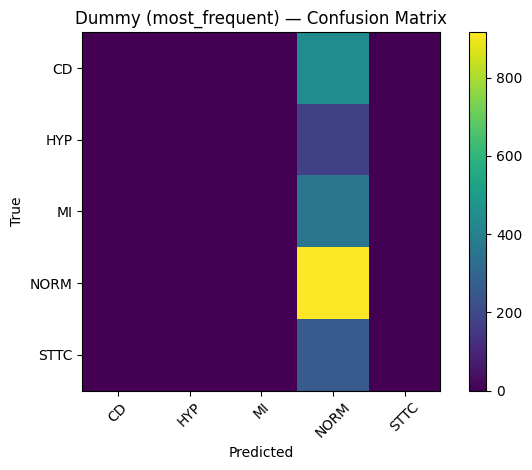


=== LogReg ===
              precision    recall  f1-score   support

          CD      0.569     0.528     0.548       445
         HYP      0.598     0.316     0.414       174
          MI      0.436     0.303     0.357       360
        NORM      0.635     0.878     0.737       916
        STTC      0.441     0.228     0.301       263

    accuracy                          0.585      2158
   macro avg      0.536     0.451     0.471      2158
weighted avg      0.561     0.585     0.555      2158



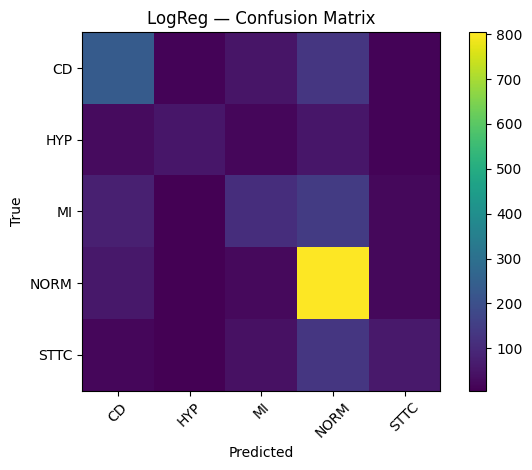


=== LinearSVM (calibrated) ===
              precision    recall  f1-score   support

          CD      0.567     0.512     0.538       445
         HYP      0.537     0.247     0.339       174
          MI      0.463     0.228     0.305       360
        NORM      0.596     0.910     0.721       916
        STTC      0.440     0.167     0.242       263

    accuracy                          0.570      2158
   macro avg      0.521     0.413     0.429      2158
weighted avg      0.544     0.570     0.525      2158



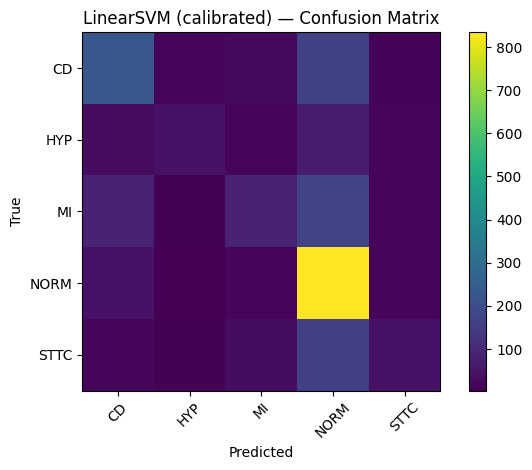


=== RandomForest ===
              precision    recall  f1-score   support

          CD      0.534     0.546     0.540       445
         HYP      0.449     0.586     0.509       174
          MI      0.425     0.314     0.361       360
        NORM      0.725     0.715     0.720       916
        STTC      0.366     0.426     0.394       263

    accuracy                          0.568      2158
   macro avg      0.500     0.517     0.505      2158
weighted avg      0.569     0.568     0.566      2158



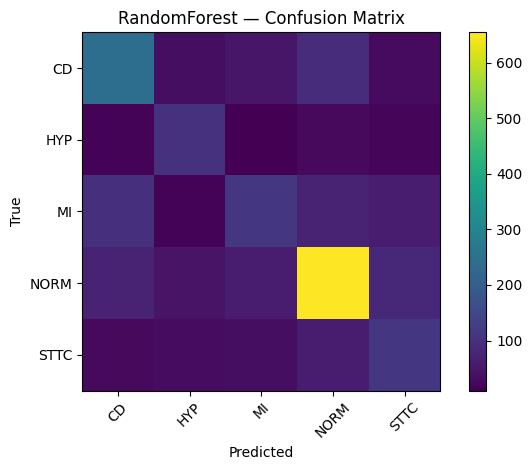


=== RF + SMOTE ===
              precision    recall  f1-score   support

          CD      0.586     0.573     0.580       445
         HYP      0.447     0.586     0.507       174
          MI      0.409     0.325     0.362       360
        NORM      0.713     0.766     0.739       916
        STTC      0.387     0.331     0.357       263

    accuracy                          0.585      2158
   macro avg      0.509     0.516     0.509      2158
weighted avg      0.575     0.585     0.578      2158



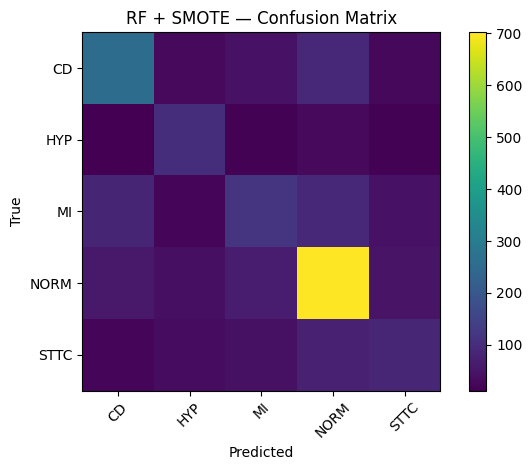

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_macro
4,RF + SMOTE,0.585264,0.508550,0.516283,0.508948,0.577965,0.813770
3,RandomForest,0.567655,0.499758,0.517417,0.504641,0.566099,0.810900
1,LogReg,0.585264,0.535716,0.450565,0.471210,0.555236,0.812541
2,LinearSVM (calibrated),0.570436,0.520816,0.413009,0.429059,0.524645,0.810539
0,Dummy (most_frequent),0.424467,0.084893,0.200000,0.119193,0.252968,0.500000


In [8]:
# === Section 6: Evaluation & Comparison ===
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier

models = {
    "LogReg": lr_gs,                          # GridSearchCV(Pipeline)
    "LinearSVM (calibrated)": svm_calibrated, # CalibratedClassifierCV(Pipeline)
    "RandomForest": rf_gs                      # GridSearchCV(Pipeline)
}
if HAS_SMOTE:
    models["RF + SMOTE"] = rf_smote

def eval_model(name, model, X_in, y_true, show_cm=True):
    y_pred = model.predict(X_in)
    try:
        y_proba = model.predict_proba(X_in); has_proba = True
    except Exception:
        y_proba = None; has_proba = False

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    if has_proba:
        from sklearn.preprocessing import label_binarize
        classes = np.unique(y_true)
        y_bin = label_binarize(y_true, classes=classes)
        try:
            metrics["roc_auc_ovr_macro"] = roc_auc_score(y_bin, y_proba, average="macro", multi_class="ovr")
        except Exception:
            pass

    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    if show_cm:
        cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
        plt.figure()
        plt.imshow(cm, interpolation='nearest')
        plt.title(f"{name} — Confusion Matrix"); plt.colorbar()
        ticks = np.arange(len(np.unique(y_true)))
        plt.xticks(ticks, np.unique(y_true), rotation=45); plt.yticks(ticks, np.unique(y_true))
        plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()
    return metrics

# Baseline: most-frequent
dummy_pipe = Pipeline([("prep", preprocessor), ("clf", DummyClassifier(strategy="most_frequent"))])
dummy_pipe.fit(X_train, y_train)

results = [eval_model("Dummy (most_frequent)", dummy_pipe, X_test, y_test)]
for n, m in models.items():
    results.append(eval_model(n, m, X_test, y_test))

res_df = pd.DataFrame(results).sort_values("f1_weighted", ascending=False)
display(res_df)


6.1) Learning curves (data-efficiency)

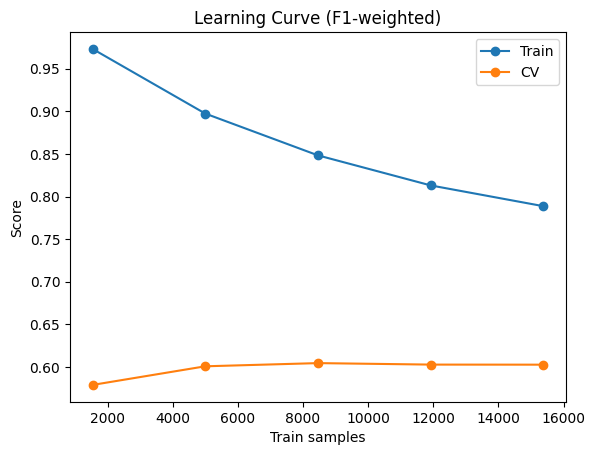

In [9]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

est = rf_gs.best_estimator_  # or lr_gs.best_estimator_
tsizes = np.linspace(0.1, 1.0, 5)
train_sizes, train_scores, val_scores = learning_curve(
    est, X_train, y_train, cv=5, n_jobs=-1, scoring="f1_weighted",
    train_sizes=tsizes, shuffle=True, random_state=SEED
)
plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV")
plt.title("Learning Curve (F1-weighted)"); plt.xlabel("Train samples"); plt.ylabel("Score"); plt.legend(); plt.show()


6.2) Calibration / reliability diagram

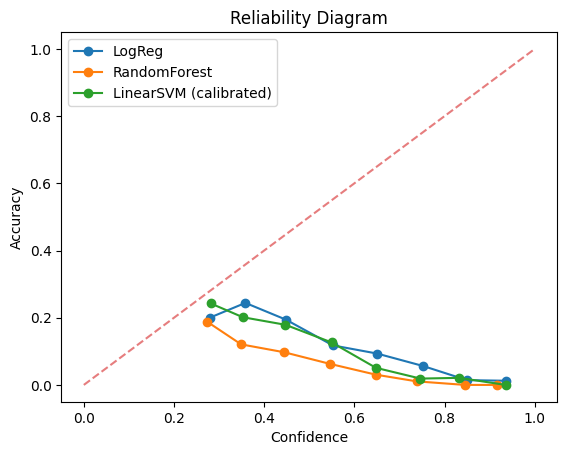

In [10]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd

def reliability_diagram(model, X, y, bins=10):
    proba = model.predict_proba(X)
    conf  = proba.max(axis=1)
    preds = proba.argmax(axis=1)
    y_enc = pd.factorize(y)[0]
    correct = (preds == y_enc).astype(int)
    edges = np.linspace(0,1,bins+1); idx = np.digitize(conf, edges)-1
    bin_conf, bin_acc = [], []
    for b in range(bins):
        m = idx==b
        if m.sum()==0: bin_conf.append(np.nan); bin_acc.append(np.nan)
        else:
            bin_conf.append(conf[m].mean()); bin_acc.append(correct[m].mean())
    return np.array(bin_conf), np.array(bin_acc)

plt.figure()
for name in ["LogReg","RandomForest","LinearSVM (calibrated)"]:
    if hasattr(models[name], "predict_proba"):
        mconf, macc = reliability_diagram(models[name], X_test, y_test, bins=10)
        plt.plot(mconf, macc, marker="o", label=name)
plt.plot([0,1],[0,1],"--", alpha=.6)
plt.xlabel("Confidence"); plt.ylabel("Accuracy"); plt.title("Reliability Diagram"); plt.legend(); plt.show()


6.3) Bootstrap confidence intervals for F1-weighted

In [11]:
from sklearn.metrics import f1_score
rng = np.random.default_rng(SEED)

def bootstrap_f1w(model, X, y, B=200):
    n = len(y); scores = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        Xi = X.iloc[idx] if hasattr(X, "iloc") else X[idx]
        yi = y.iloc[idx] if hasattr(y, "iloc") else y[idx]
        y_hat = model.predict(Xi)
        scores.append(f1_score(yi, y_hat, average="weighted", zero_division=0))
    m = float(np.mean(scores)); lo, hi = np.percentile(scores, [5,95]).tolist()
    return m, lo, hi

for name, model in models.items():
    m, lo, hi = bootstrap_f1w(model, X_test, y_test, B=200)
    print(f"{name}: F1_weighted={m:.3f} (95% CI {lo:.3f}–{hi:.3f})")


LogReg: F1_weighted=0.554 (95% CI 0.536–0.572)
LinearSVM (calibrated): F1_weighted=0.526 (95% CI 0.508–0.543)
RandomForest: F1_weighted=0.565 (95% CI 0.546–0.583)
RF + SMOTE: F1_weighted=0.578 (95% CI 0.561–0.596)


6.4) Error analysis: top confusions + sample rows

In [12]:
import itertools
from sklearn.metrics import confusion_matrix

rf = models["RandomForest"]
y_pred = rf.predict(X_test)
labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred, labels=labels)

pairs = []
for i,j in itertools.product(range(len(labels)), repeat=2):
    if i!=j: pairs.append((labels[i], labels[j], cm[i,j]))
pairs = sorted(pairs, key=lambda x: -x[2])[:5]
print("Top confused pairs (true→pred, count):", pairs)

mis = (y_test != y_pred)
err_df = pd.DataFrame({"true": y_test[mis], "pred": y_pred[mis]})
print("\nExample misclassifications:")
display(err_df.head(10))


Top confused pairs (true→pred, count): [(np.str_('MI'), np.str_('CD'), np.int64(97)), (np.str_('CD'), np.str_('NORM'), np.int64(91)), (np.str_('NORM'), np.str_('STTC'), np.int64(83)), (np.str_('MI'), np.str_('NORM'), np.int64(72)), (np.str_('NORM'), np.str_('CD'), np.int64(72))]

Example misclassifications:


,true,pred
32,NORM,CD
57,MI,NORM
59,CD,NORM
113,NORM,STTC
122,STTC,CD
146,STTC,MI
153,STTC,NORM
161,MI,NORM
195,MI,CD
203,CD,NORM


7) Interpretation (RF importance, permutation; LR coefficients)

In [13]:
# === Section 7: Interpretation ===
import numpy as np
from sklearn.inspection import permutation_importance

def get_feature_names(prep):
    try: return prep.get_feature_names_out().tolist()
    except Exception:
        n_feats = prep.fit_transform(X_train).shape[1]
        return [f"f{i}" for i in range(n_feats)]

feat_names = get_feature_names(preprocessor)

# RF impurity importances
try:
    rf_best = models["RandomForest"].best_estimator_
    imp = rf_best.named_steps["clf"].feature_importances_
    idx = np.argsort(imp)[::-1][:20]
    print("Top RF features (impurity):")
    for i in idx:
        print(f"{feat_names[i]:40s} {imp[i]:.4f}")
except Exception as e:
    print("RF importance unavailable:", e)

# Permutation importance
try:
    r = permutation_importance(rf_best, X_test, y_test, n_repeats=5, random_state=SEED, scoring="f1_weighted")
    fn = feat_names if len(feat_names)==len(r.importances_mean) else np.arange(len(r.importances_mean))
    idx = np.argsort(r.importances_mean)[::-1][:20]
    print("\nTop features (permutation):")
    for i in idx:
        print(f"{fn[i]}  {r.importances_mean[i]:.4f} ± {r.importances_std[i]:.4f}")
except Exception as e:
    print("Permutation importance skipped:", e)

# LR coefficients
try:
    lr_best = models["LogReg"].best_estimator_
    coef = lr_best.named_steps["clf"].coef_
    mag = np.mean(np.abs(coef), axis=0)
    idx = np.argsort(mag)[::-1][:20]
    print("\nTop LR features by |coef|:")
    for i in idx:
        print(f"{feat_names[i]:40s} {mag[i]:.4f}")
except Exception as e:
    print("LR coefficients unavailable:", e)


Top RF features (impurity):
num__L10_rms                             0.0361
num__L1_skew                             0.0355
num__L10_std                             0.0353
num__L3_skew                             0.0343
num__L3_kurt                             0.0289
num__L11_rms                             0.0252
num__L11_std                             0.0229
num__L6_rms                              0.0209
num__L6_std                              0.0199
num__L10_skew                            0.0189
num__L3_p50                              0.0188
num__L6_skew                             0.0185
num__L8_p50                              0.0179
num__L3_std                              0.0177
num__L9_p50                              0.0173
num__L3_rms                              0.0172
num__L5_skew                             0.0160
num__L1_p50                              0.0157
num__L0_kurt                             0.0137
num__L0_skew                             0.0135

Top feature

8) Centralized Deep Learning (MLP) — Baseline

In [14]:
# === Section 8: Centralized DL Baseline (MLP) ===
if TORCH_OK:
    import torch, torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.preprocessing import LabelEncoder

    Xtr_arr = preprocessor.fit_transform(X_train)
    Xte_arr = preprocessor.transform(X_test)
    if not isinstance(Xtr_arr, np.ndarray):
        Xtr_arr = Xtr_arr.toarray(); Xte_arr = Xte_arr.toarray()

    le = LabelEncoder()
    ytr_arr = le.fit_transform(y_train.values); yte_arr = le.transform(y_test.values)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class MLP(nn.Module):
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 128), nn.ReLU(),
                nn.Linear(128, 64), nn.ReLU(),
                nn.Linear(64, out_dim)
            )
        def forward(self, x): return self.net(x)

    model = MLP(Xtr_arr.shape[1], len(np.unique(ytr_arr))).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()

    train_loader = DataLoader(TensorDataset(torch.tensor(Xtr_arr, dtype=torch.float32),
                                            torch.tensor(ytr_arr, dtype=torch.long)), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(Xte_arr, dtype=torch.float32),
                                           torch.tensor(yte_arr, dtype=torch.long)), batch_size=256, shuffle=False)

    def epoch(loader, train=True):
        model.train() if train else model.eval()
        correct, total = 0, 0
        with torch.set_grad_enabled(train):
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                if train: opt.zero_grad()
                logits = model(xb)
                loss = crit(logits, yb)
                if train: loss.backward(); opt.step()
                pred = logits.argmax(1); correct += (pred==yb).sum().item(); total += xb.size(0)
        return correct / max(total,1)

    for e in range(5):
        tr = epoch(train_loader, True)
        te = epoch(test_loader, False)
        print(f"Epoch {e+1}: train_acc={tr:.3f}  test_acc={te:.3f}")
else:
    print("Torch not available — skipping centralized DL baseline.")


Epoch 1: train_acc=0.584  test_acc=0.583
Epoch 2: train_acc=0.632  test_acc=0.591
Epoch 3: train_acc=0.645  test_acc=0.608
Epoch 4: train_acc=0.660  test_acc=0.606
Epoch 5: train_acc=0.664  test_acc=0.614


9) Federated Learning (non-IID Dirichlet) with Sample-Weighted FedAvg + Communication


In [15]:
# === Section 9: Federated Learning (non-IID, sample-weighted FedAvg) ===
if TORCH_OK:
    import torch, torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.preprocessing import LabelEncoder

    # Preprocess to arrays
    prep = preprocessor.fit(X_train, y_train)
    Xtr = prep.transform(X_train); Xte = prep.transform(X_test)
    if not isinstance(Xtr, np.ndarray): Xtr = Xtr.toarray(); Xte = Xte.toarray()

    le = LabelEncoder(); ytr = le.fit_transform(y_train.values); yte = le.transform(y_test.values)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class MLP(nn.Module):
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(in_dim,128), nn.ReLU(),
                                     nn.Linear(128,64), nn.ReLU(),
                                     nn.Linear(64,out_dim))
        def forward(self, x): return self.net(x)

    def get_weights(m): return [p.detach().cpu().clone() for p in m.parameters()]
    def set_weights(m, ws):
        with torch.no_grad():
            for p,w in zip(m.parameters(), ws): p.copy_(w)
    def avg_weights_weighted(weights_list, sizes):
        total = float(sum(sizes))
        out = [w.clone().mul_(sizes[0]/total) for w in weights_list[0]]
        for ws, n in zip(weights_list[1:], sizes[1:]):
            for i in range(len(out)): out[i].add_(ws[i], alpha=n/total)
        return out

    def dirichlet_partition(y, K=4, alpha=0.3, seed=SEED):
        rng = np.random.default_rng(seed)
        classes = np.unique(y)
        idx_per_client = [[] for _ in range(K)]
        for c in classes:
            idx_c = np.where(y==c)[0]; rng.shuffle(idx_c)
            props = rng.dirichlet([alpha]*K)
            splits = np.cumsum(np.round(props*len(idx_c))).astype(int); splits[-1] = len(idx_c)
            prev = 0
            for k, cut in enumerate(splits):
                idx_per_client[k].extend(idx_c[prev:cut].tolist()); prev = cut
        for k in range(K): rng.shuffle(idx_per_client[k])
        return [np.array(v, dtype=int) for v in idx_per_client]

    K = 4
    splits = dirichlet_partition(ytr, K=K, alpha=0.3)
    sizes = [len(s) for s in splits]

    def make_loader(idx):
        return DataLoader(TensorDataset(torch.tensor(Xtr[idx], dtype=torch.float32),
                                        torch.tensor(ytr[idx], dtype=torch.long)),
                          batch_size=64, shuffle=True)
    client_loaders = [make_loader(s) for s in splits]
    test_loader = DataLoader(TensorDataset(torch.tensor(Xte, dtype=torch.float32),
                                           torch.tensor(yte, dtype=torch.long)), batch_size=256, shuffle=False)

    # Centralized baseline
    base = MLP(Xtr.shape[1], len(np.unique(ytr))).to(device)
    opt = torch.optim.Adam(base.parameters(), lr=1e-3); crit = nn.CrossEntropyLoss()
    for _ in range(5):
        base.train()
        for xb,yb in DataLoader(TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                                             torch.tensor(ytr, dtype=torch.long)), batch_size=64, shuffle=True):
            xb,yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(base(xb), yb); loss.backward(); opt.step()

    def acc(m, loader):
        m.eval(); c=t=0
        with torch.no_grad():
            for xb,yb in loader:
                xb,yb = xb.to(device), yb.to(device)
                c += (m(xb).argmax(1)==yb).sum().item(); t += xb.size(0)
        return c/max(t,1)

    base_acc = acc(base, test_loader)
    print("Centralized MLP acc:", round(base_acc,3))

    # FedAvg + communication estimate (float32 params)
    global_model = MLP(Xtr.shape[1], len(np.unique(ytr))).to(device)
    ROUNDS = 5
    param_bytes = sum(p.numel() for p in global_model.parameters()) * 4
    total_comm_bytes = 0

    for r in range(ROUNDS):
        ws = []
        for loader in client_loaders:
            local = MLP(Xtr.shape[1], len(np.unique(ytr))).to(device)
            set_weights(local, get_weights(global_model))
            opt = torch.optim.Adam(local.parameters(), lr=1e-3); crit = nn.CrossEntropyLoss()
            local.train()
            for xb,yb in loader:
                xb,yb = xb.to(device), yb.to(device)
                opt.zero_grad(); loss = crit(local(xb), yb); loss.backward(); opt.step()
            ws.append(get_weights(local))
            total_comm_bytes += param_bytes           # upload
        set_weights(global_model, avg_weights_weighted(ws, sizes))
        total_comm_bytes += K * param_bytes          # broadcast
        print(f"Round {r+1} — FedAvg test acc:", round(acc(global_model, test_loader), 3))

    print(f"Total communication ≈ {total_comm_bytes/1e6:.2f} MB over {ROUNDS} rounds ({K} clients)")
else:
    print("Torch not available — skipping FL simulation.")


Centralized MLP acc: 0.61
Round 1 — FedAvg test acc: 0.556
Round 2 — FedAvg test acc: 0.576
Round 3 — FedAvg test acc: 0.59
Round 4 — FedAvg test acc: 0.595
Round 5 — FedAvg test acc: 0.594
Total communication ≈ 3.36 MB over 5 rounds (4 clients)


10) Subgroup Fairness (sex + age bins)

In [16]:
# === Section 10: Subgroup Fairness Checks ===
meta_cols = ["ecg_id","patient_id","age","sex","height","weight","nurse","site","device",
             "recording_date","report","scp_codes","heart_axis","infarction_stadium1","infarction_stadium2",
             "validated_by","second_opinion","initial_autogenerated_report","validated_by_human",
             "baseline_drift","static_noise","burst_noise","electrodes_problems","extra_beats",
             "pacemaker","strat_fold","record_path"]

test_index = X_test.index
test_meta = df.loc[test_index, meta_cols + ["label"]].copy()
test_meta["pred_RF"]  = models["RandomForest"].predict(X_test)
test_meta["pred_LR"]  = models["LogReg"].predict(X_test)
test_meta["pred_SVM"] = models["LinearSVM (calibrated)"].predict(X_test)

from sklearn.metrics import f1_score

print("\nWeighted F1 by sex (RF):")
for g, gdf in test_meta.groupby("sex"):
    f1w = f1_score(gdf["label"], gdf["pred_RF"], average="weighted", zero_division=0)
    print(f"  sex={g}: {f1w:.3f} (n={len(gdf)})")

bins = [-np.inf, 40, 65, np.inf]
labels = ["<40", "40–65", "65+"]
test_meta["age_bin"] = pd.cut(test_meta["age"], bins=bins, labels=labels)

print("\nWeighted F1 by age_bin (RF):")
for g, gdf in test_meta.groupby("age_bin"):
    f1w = f1_score(gdf["label"], gdf["pred_RF"], average="weighted", zero_division=0)
    print(f"  age_bin={g}: {f1w:.3f} (n={len(gdf)})")

# Quick optional groups
for col in ["site","device","pacemaker"]:
    if col in test_meta.columns:
        print(f"\nWeighted F1 by {col} (RF):")
        for g, gdf in test_meta.groupby(col):
            if len(gdf):
                f1w = f1_score(gdf["label"], gdf["pred_RF"], average="weighted", zero_division=0)
                print(f"  {col}={g}: {f1w:.3f} (n={len(gdf)})")



Weighted F1 by sex (RF):
  sex=0: 0.580 (n=1110)
  sex=1: 0.552 (n=1048)

Weighted F1 by age_bin (RF):
  age_bin=<40: 0.699 (n=310)
  age_bin=40–65: 0.585 (n=883)
  age_bin=65+: 0.506 (n=965)

Weighted F1 by site (RF):
  site=0.0: 0.632 (n=483)
  site=1.0: 0.543 (n=598)
  site=2.0: 0.554 (n=867)
  site=3.0: 0.573 (n=103)
  site=4.0: 0.626 (n=16)
  site=5.0: 0.467 (n=5)
  site=6.0: 0.333 (n=4)
  site=7.0: 0.286 (n=7)
  site=8.0: 0.222 (n=6)
  site=9.0: 0.417 (n=4)
  site=10.0: 0.250 (n=4)
  site=11.0: 0.444 (n=3)
  site=12.0: 0.800 (n=5)
  site=13.0: 1.000 (n=3)
  site=14.0: 0.333 (n=4)
  site=15.0: 0.324 (n=7)
  site=16.0: 0.500 (n=2)
  site=17.0: 0.222 (n=3)
  site=18.0: 1.000 (n=1)
  site=19.0: 1.000 (n=2)
  site=20.0: 0.125 (n=4)
  site=21.0: 1.000 (n=1)
  site=24.0: 0.000 (n=1)
  site=25.0: 0.444 (n=3)
  site=26.0: 1.000 (n=1)
  site=27.0: 1.000 (n=1)
  site=28.0: 0.667 (n=3)
  site=29.0: 0.667 (n=2)
  site=30.0: 1.000 (n=2)
  site=31.0: 0.000 (n=1)
  site=32.0: 0.000 (n=3)
  site

11) Ethics, Fairness & Sustainability — notes for the report

In [17]:
# === Section 11: Ethics, Fairness & Sustainability (notes) ===
ethics_notes = {
    "privacy_consent": "Dataset license, de-identification, lawful basis, reuse boundaries.",
    "fairness": "Subgroup performance (sex, age, device/site); imbalance handling; calibration.",
    "safety": "Clinical risk of FP/FN; human-in-the-loop; monitoring & rollback.",
    "sustainability": "Model efficiency; FedAvg communication (MB printed), limit epochs, cache, fixed seeds.",
    "reproducibility": "Fixed seeds, pinned versions, deterministic transforms, saved artifacts."
}
print(json.dumps(ethics_notes, indent=2))


{
  "privacy_consent": "Dataset license, de-identification, lawful basis, reuse boundaries.",
  "fairness": "Subgroup performance (sex, age, device/site); imbalance handling; calibration.",
  "safety": "Clinical risk of FP/FN; human-in-the-loop; monitoring & rollback.",
  "sustainability": "Model efficiency; FedAvg communication (MB printed), limit epochs, cache, fixed seeds.",
  "reproducibility": "Fixed seeds, pinned versions, deterministic transforms, saved artifacts."
}


12) Save Artifacts & Create One ZIP (models, metrics, environment)

In [18]:
# === Section 12: Artifacts & ZIP bundle ===
ART_DIR = "test/artifacts"; os.makedirs(ART_DIR, exist_ok=True)

# Save best models
import joblib, sys, subprocess, zipfile, glob
joblib.dump(lr_gs.best_estimator_, os.path.join(ART_DIR, "lr_best.joblib"))
joblib.dump(rf_gs.best_estimator_, os.path.join(ART_DIR, "rf_best.joblib"))
joblib.dump(svm_calibrated,         os.path.join(ART_DIR, "svm_calibrated.joblib"))

# Metrics table
res_path = os.path.join(ART_DIR, "results_table.csv")
pd.DataFrame(locals().get("res_df", pd.DataFrame())).to_csv(res_path, index=False)

# Best params JSON
summary = {
    "time": ts(),
    "label_mode": LABEL_MODE,
    "lr_best_params": getattr(lr_gs, "best_params_", None),
    "rf_best_params": getattr(rf_gs, "best_params_", None),
    "svm_best_params": getattr(svm_gs, "best_params_", None),
}
with open(os.path.join(ART_DIR, "best_params.json"), "w") as f:
    json.dump(summary, f, indent=2)

# Freeze environment (best-effort)
try:
    req = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True)
    with open(os.path.join(ART_DIR, "requirements.txt"), "w") as f:
        f.write(req)
except Exception:
    pass

# Include feature CSV + artifacts in one ZIP
ZIP_OUT = "test/submission_bundle.zip"
with zipfile.ZipFile(ZIP_OUT, "w", zipfile.ZIP_DEFLATED) as z:
    for p in glob.glob(os.path.join(ART_DIR, "*")):
        z.write(p, arcname=os.path.join("artifacts", os.path.basename(p)))
    if os.path.exists("PTB-XL2022/ptbxl_features.csv"):
        z.write("PTB-XL2022/ptbxl_features.csv", arcname="ptbxl_features.csv")
print("Created bundle:", ZIP_OUT)


Created bundle: test/submission_bundle.zip


13) (Optional) Quick raw-ECG viewer for a misclassified record

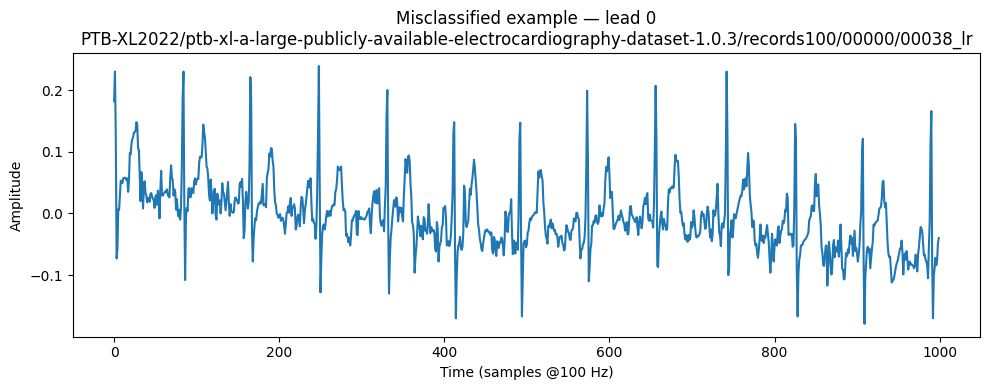

In [19]:
# === Section 13 (optional): Inspect a raw ECG for a misclassification ===
try:
    import wfdb
    # pull first misclassified example from RF predictions
    rf = models["RandomForest"]; y_pred = rf.predict(X_test)
    mis_mask = (y_test != y_pred)
    if mis_mask.any():
        idx = X_test.index[mis_mask][0]
        rec_path = df.loc[idx, "record_path"]
        sig, meta = wfdb.rdsamp(rec_path)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,4))
        plt.plot(sig[:,0])  # lead 0
        plt.title(f"Misclassified example — lead 0\n{rec_path}")
        plt.xlabel("Time (samples @100 Hz)"); plt.ylabel("Amplitude")
        plt.tight_layout(); plt.show()
    else:
        print("No misclassifications to display.")
except Exception as e:
    print("Raw viewer skipped:", e)


14. Female vs Male: NORM / MI / STTC / CD / HYP

Top remaining unmapped codes: [('SR', 16748), ('AFIB', 1514), ('PVC', 1143), ('STACH', 826), ('SARRH', 772), ('SBRAD', 637), ('QWAVE', 548), ('PAC', 398), ('LPR', 340), ('PACE', 294), ('LVOLT', 182), ('SVARR', 157), ('BIGU', 82), ('AFLT', 73), ('TAB_', 35), ('SVTAC', 27), ('PSVT', 24), ('TRIGU', 20), ('PRC(S)', 10)]
Mapped ECGs: 21413 (male=11130, female=10283)

Counts by sex x class:
 superclass  NORM    MI  STTC    CD  HYP
sex_label                              
male        4220  2545  1496  2120  749
female      5023  1504  1870  1328  558

Prevalence within sex (%):
 superclass   NORM     MI   STTC     CD   HYP
sex_label                                   
male        37.92  22.87  13.44  19.05  6.73
female      48.85  14.63  18.19  12.91  5.43

Chi-square per superclass:
        count_male  count_female  total_male  total_female        chi2  \
class                                                                   
NORM         4220          5023       11130         10283  260.3716

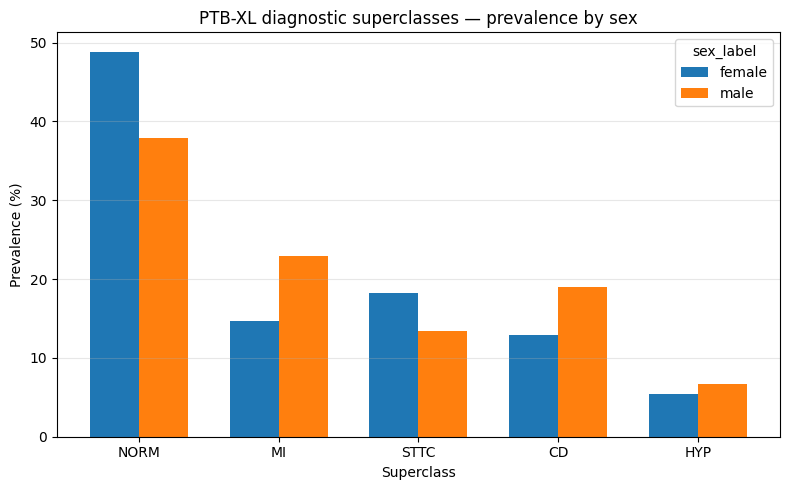

In [20]:
# ==== Section 14 — Male vs Female prevalence (PTB-XL; subclass-aware mapping) ====

import os, ast, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

ROOT = "PTB-XL2022/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
DB_CSV  = os.path.join(ROOT, "ptbxl_database.csv")
SCP_CSV = os.path.join(ROOT, "scp_statements.csv")

CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]

# ----------------- helpers -----------------
def parse_scp_dict(s):
    if pd.isna(s): 
        return {}
    for loader in (ast.literal_eval, json.loads):
        try:
            d = loader(s)
            return d if isinstance(d, dict) else {}
        except Exception:
            pass
    return {}

def class_from_subclass(sub):
    """Map diagnostic_subclass to top-level 5-way superclass."""
    if not isinstance(sub, str):
        return None
    su = sub.upper().strip()
    if su == "NORM":
        return "NORM"
    if su.endswith("MI") or su in {"IMI","AMI","PMI"}:
        return "MI"
    if ("AVB" in su) or ("BBB" in su) or su in {"_AVB","BIFB","TRIFB","LAFB","LPFB","LPR"}:
        return "CD"
    if "HYP" in su or su in {"SEHYP"}:
        return "HYP"
    if su in {"ISCA","ISC_","NST_","NDT","DIG","STTC"} or su.startswith("NST"):
        return "STTC"
    return None

# Optional: add a tiny supplemental mapping for frequent codes not labeled in your CSV.
# (We leave rhythm-only codes like SR/AFIB/PAC/SBRAD/STACH unmapped on purpose.)
EXTRA_CODE_MAP = {
    "ABQRS": "CD",     # QRS abnormality -> conduction
    "VCLVH": "HYP",    # voltage criteria LVH -> hypertrophy
    "HVOLT": "HYP",    # high voltage -> hypertrophy
    "STD_":  "STTC",   # ST depression (generic)
    "STE_":  "STTC",   # ST elevation (generic)
    "LOWT":  "STTC",   # low T
    "INVT":  "STTC",   # inverted T
    "NT_":   "STTC",   # T negativity (generic)
    # leave QWAVE undecided (often MI marker) unless you want to force: "QWAVE": "MI"
}

# ----------------- load -----------------
db  = pd.read_csv(DB_CSV)
scp = pd.read_csv(SCP_CSV)

# ----------------- normalize sex -----------------
if db["sex"].dtype != "O":
    db["sex_label"] = db["sex"].map({0: "male", 1: "female"})
else:
    db["sex_label"] = db["sex"].astype(str).str.lower().str.strip()
db = db[db["sex_label"].isin(["male","female"])].copy()

# ----------------- build mapping from scp_statements -----------------
# Use your exact columns
code_col  = "scp_codes"
class_col = "diagnostic_class"
sub_col   = "diagnostic_subclass" if "diagnostic_subclass" in scp.columns else None

m = scp[[c for c in [code_col, class_col, sub_col] if c is not None]].copy()
for c in [code_col, class_col, sub_col]:
    if c in m.columns:
        m[c] = m[c].astype(str).str.upper().str.strip()

# Direct code -> class where class is one of the 5-way targets
m_direct = m[m[class_col].isin(CLASSES)][[code_col, class_col]].dropna()
CODE2CLASS = dict(zip(m_direct[code_col], m_direct[class_col]))

# Fallback: code -> subclass (then subclass -> class)
CODE2SUB = {}
if sub_col in m.columns:
    tmp = m[(~m[sub_col].isna()) & (m[class_col].isna())][[code_col, sub_col]].dropna()
    CODE2SUB = dict(zip(tmp[code_col], tmp[sub_col]))

def lookup_superclass(code):
    cu = str(code).upper().strip()
    # 1) direct from diagnostic_class
    if cu in CODE2CLASS:
        return CODE2CLASS[cu]
    # 2) via diagnostic_subclass, then rule-based to top-level
    sub = CODE2SUB.get(cu)
    if sub:
        klass = class_from_subclass(sub)
        if klass in CLASSES:
            return klass
    # 3) small extra map for frequent codes
    if cu in EXTRA_CODE_MAP:
        return EXTRA_CODE_MAP[cu]
    # 4) nothing
    return None

# ----------------- assign superclass per ECG (aggregate probs, argmax) -----------------
db["_scp_dict"] = db["scp_codes"].map(parse_scp_dict)

def assign_superclass(d: dict):
    if not isinstance(d, dict) or not d:
        return np.nan
    agg = {}
    for code, prob in d.items():
        klass = lookup_superclass(code)
        if klass in CLASSES:
            agg[klass] = agg.get(klass, 0.0) + float(prob)
    if not agg:
        return np.nan
    return max(agg.items(), key=lambda kv: kv[1])[0]

db["superclass"] = db["_scp_dict"].map(assign_superclass)
df = db.dropna(subset=["superclass"]).copy()
df = df[df["superclass"].isin(CLASSES)]

# ----------------- diagnostics -----------------
# what codes are still unmapped?
from collections import Counter
all_codes = []
for d in db["_scp_dict"]:
    if isinstance(d, dict):
        all_codes.extend([str(k).upper().strip() for k in d.keys()])
code_counts = Counter(all_codes)
unmapped = [(c,n) for c,n in code_counts.items() if lookup_superclass(c) is None]
unmapped = sorted(unmapped, key=lambda x: x[1], reverse=True)[:25]
print("Top remaining unmapped codes:", unmapped)

# ----------------- counts / prevalence / chi-square -----------------
tm = int((df["sex_label"] == "male").sum())
tf = int((df["sex_label"] == "female").sum())
print(f"Mapped ECGs: {len(df)} (male={tm}, female={tf})")

# counts table
ct = pd.crosstab(df["sex_label"], df["superclass"]).reindex(index=["male","female"], columns=CLASSES, fill_value=0)
prev = ct.div(ct.sum(axis=1), axis=0)*100

print("\nCounts by sex x class:\n", ct)
print("\nPrevalence within sex (%):\n", prev.round(2))

# chi-square per class (2x2)
chi_rows = []
for c in CLASSES:
    nm = int(((df["sex_label"]=="male") & (df["superclass"]==c)).sum())
    nf = int(((df["sex_label"]=="female") & (df["superclass"]==c)).sum())
    table = np.array([[nm, tm-nm],[nf, tf-nf]])
    chi2, p, dof, _ = chi2_contingency(table, correction=False)
    chi_rows.append([c, nm, nf, tm, tf, chi2, p, dof])
chi_df = pd.DataFrame(chi_rows, columns=["class","count_male","count_female","total_male","total_female","chi2","p_value","dof"]).set_index("class")
print("\nChi-square per superclass:\n", chi_df)

# ----------------- plot -----------------
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(CLASSES)); width = 0.35
ax.bar(x - width/2, prev.loc["female", CLASSES].to_numpy(), width, label="female")
ax.bar(x + width/2, prev.loc["male", CLASSES].to_numpy(),   width, label="male")
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylabel("Prevalence (%)"); ax.set_xlabel("Superclass")
ax.set_title("PTB-XL diagnostic superclasses — prevalence by sex")
ax.legend(title="sex_label"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
